# Brain Tumor Detection using Modern PyTorch

This notebook demonstrates a complete pipeline for binary classification of
brain MRI images (Tumor vs No-Tumor) using a fine-tuned **ResNet-50** model
in **PyTorch**.

**Highlights:**
- Pre-trained ResNet-50 with transfer learning
- OpenCV-based brain contour cropping (preprocessing)
- Rich visual outputs: training curves, confusion matrix, sample predictions
- Clean, human-readable variable names throughout

## 0. Install Dependencies

Run this cell if you are running outside of Kaggle/Colab, or if any specific libraries are missing.

In [1]:
import sys
!{sys.executable} -m pip install -q torch torchvision matplotlib seaborn scikit-learn tqdm opencv-python pillow kagglehub

## 1. Install & Import Dependencies

In [2]:
import os
import sys
import random
import time
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models, datasets

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Pretty plotting defaults
sns.set_style("darkgrid")
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.9.0+cu126
CUDA available  : True
GPU             : Tesla T4


## 1.5 Download Dataset

We use `kagglehub` to download the dataset automatically if it isn't already present.

In [3]:
import kagglehub

print("Downloading dataset...")
# Download BRATS 2019 dataset
dataset_path = kagglehub.dataset_download("aryanfelix/brats-2019-traintestvalid")
print(f"Dataset downloaded to: {dataset_path}")

# The dataset structure inside has a 'dataset' folder containing 'train' and 'valid'
DATASET_ROOT = os.path.join(dataset_path, "dataset")

Dataset downloaded to: /kaggle/input/datasets/aryanfelix/brats-2019-traintestvalid


## 2. Configuration

All hyper-parameters and paths in one place for easy experimentation.

In [4]:
# ──────────────────── CONFIGURATION ────────────────────
IMAGE_SIZE        = 224          # Input resolution for ResNet
BATCH_SIZE        = 64
NUM_WORKERS       = 2            # DataLoader workers (set 0 on Windows if issues)
NUM_EPOCHS        = 25
LEARNING_RATE     = 1e-4
WEIGHT_DECAY      = 1e-4
EARLY_STOP_PATIENCE = 10          # epochs without improvement before stopping
MODEL_SAVE_PATH   = "best_brain_tumor_model.pth"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Brain Contour Cropping (Optional Preprocessing)

The original notebook used OpenCV to find the largest brain contour and
crop to its bounding box. We encapsulate this into a reusable function.

In [5]:
def crop_brain_contour(image_pil: Image.Image, add_pixels: int = 0) -> Image.Image:
    """Crop an MRI image to the bounding box of the largest brain contour.

    Parameters
    ----------
    image_pil : PIL.Image
        Input PIL image.
    add_pixels : int
        Extra padding around the detected contour.

    Returns
    -------
    PIL.Image
        Cropped image. Returns original if no contour is detected.
    """
    image_np = np.array(image_pil)
    if image_np.ndim == 2:
        gray = image_np
    else:
        gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary_mask = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    binary_mask = cv2.erode(binary_mask, None, iterations=2)
    binary_mask = cv2.dilate(binary_mask, None, iterations=2)

    contours, _ = cv2.findContours(
        binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        return image_pil  # nothing found, return as-is

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Add optional padding
    x = max(x - add_pixels, 0)
    y = max(y - add_pixels, 0)
    w = min(w + 2 * add_pixels, image_np.shape[1] - x)
    h = min(h + 2 * add_pixels, image_np.shape[0] - y)

    cropped = image_np[y : y + h, x : x + w]
    return Image.fromarray(cropped)


class BrainCropTransform:
    """A torchvision-compatible transform that crops brain contours."""

    def __init__(self, add_pixels: int = 0):
        self.add_pixels = add_pixels

    def __call__(self, image_pil: Image.Image) -> Image.Image:
        return crop_brain_contour(image_pil, self.add_pixels)

## 4. Data Loading & Augmentation

We build separate transform pipelines for training (with augmentation)
and validation/test (deterministic).

In [6]:
# ImageNet normalisation statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    BrainCropTransform(add_pixels=2),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    BrainCropTransform(add_pixels=2),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Build datasets ──
train_dir = os.path.join(DATASET_ROOT, "train")
val_dir   = os.path.join(DATASET_ROOT, "valid")

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=val_test_transforms)

class_names = train_dataset.classes  # e.g. ['no', 'yes']
num_classes = len(class_names)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"Classes         : {class_names}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Classes         : ['no', 'yes']
Training samples: 2800
Validation samples: 200


### 4.1 Visualise a Sample Batch

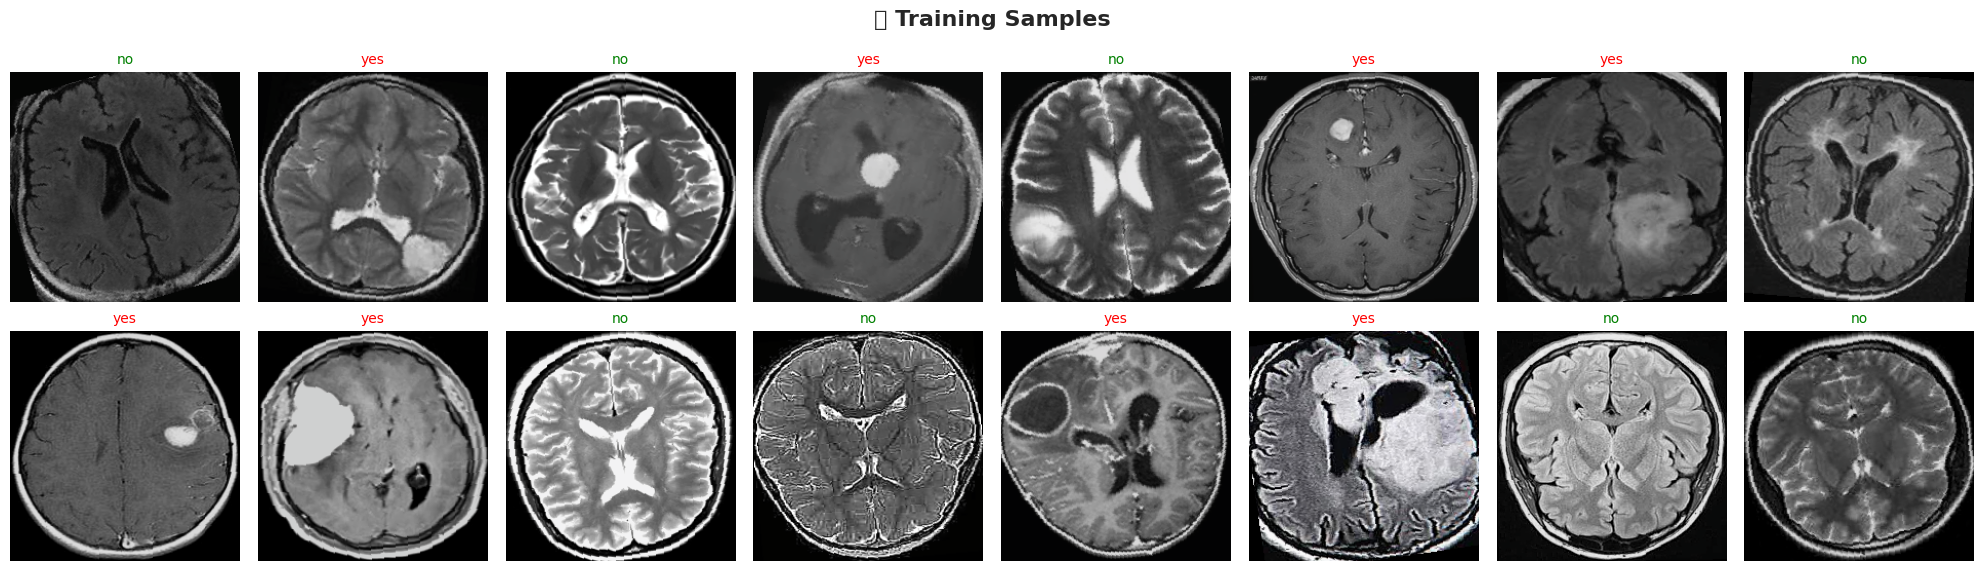

In [7]:
def show_sample_batch(loader, class_names, title="Sample Batch"):
    """Display a grid of images from a DataLoader batch."""
    images, labels = next(iter(loader))
    images = images[:16]
    labels = labels[:16]

    fig, axes = plt.subplots(2, 8, figsize=(20, 6))
    fig.suptitle(title, fontsize=16, fontweight="bold")
    for idx, ax in enumerate(axes.flat):
        if idx >= len(images):
            ax.axis("off")
            continue
        img = images[idx].permute(1, 2, 0).numpy()
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(class_names[labels[idx]], fontsize=10,
                     color="green" if class_names[labels[idx]] == "no" else "red")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_batch(train_loader, class_names, title="🧠 Training Samples")

### 4.2 Dataset Class Distribution

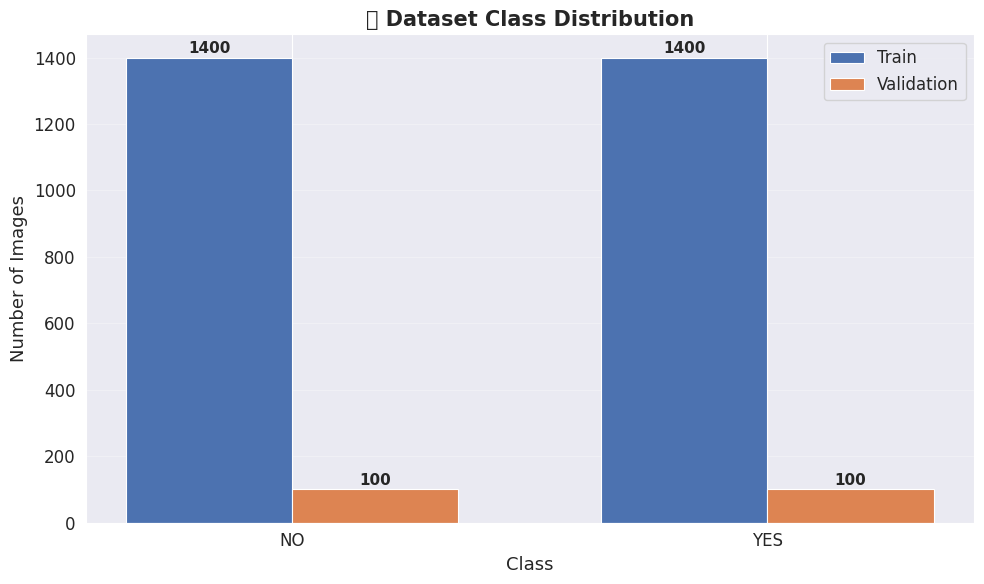

In [8]:
def plot_dataset_distribution(train_ds, val_ds, class_names):
    """Show a grouped bar chart of class counts in train & val sets."""
    from collections import Counter
    train_counts = Counter(train_ds.targets)
    val_counts   = Counter(val_ds.targets)

    x = np.arange(len(class_names))
    width = 0.35

    train_vals = [train_counts.get(i, 0) for i in range(len(class_names))]
    val_vals   = [val_counts.get(i, 0)   for i in range(len(class_names))]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars_train = ax.bar(x - width/2, train_vals, width, label="Train",
                        color="#4C72B0", edgecolor="white", linewidth=0.8)
    bars_val   = ax.bar(x + width/2, val_vals,   width, label="Validation",
                        color="#DD8452", edgecolor="white", linewidth=0.8)

    # Annotate counts on top of each bar
    for bar in bars_train:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha="center", va="bottom",
                fontsize=11, fontweight="bold")
    for bar in bars_val:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha="center", va="bottom",
                fontsize=11, fontweight="bold")

    ax.set_xlabel("Class", fontsize=13)
    ax.set_ylabel("Number of Images", fontsize=13)
    ax.set_title("📊 Dataset Class Distribution", fontsize=15, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([c.upper() for c in class_names], fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_dataset_distribution(train_dataset, val_dataset, class_names)

## 5. Model Architecture — Fine-Tuned ResNet-50

We load a pre-trained ResNet-50, freeze the early layers, and replace
the final fully-connected head for binary classification.

In [9]:
def build_brain_tumor_model(num_classes: int = 2, freeze_backbone: bool = True):
    """Build a ResNet-50 model fine-tuned for brain tumor classification.

    Parameters
    ----------
    num_classes : int
        Number of output classes (2 for binary).
    freeze_backbone : bool
        If True, freeze all convolutional layers and only train the head.

    Returns
    -------
    nn.Module
        The configured model.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the classifier head
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(num_features, 728),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(728, num_classes),
    )
    return model


brain_tumor_model = build_brain_tumor_model(num_classes=num_classes)
brain_tumor_model = brain_tumor_model.to(DEVICE)

# ── Print a short summary ──
total_params     = sum(p.numel() for p in brain_tumor_model.parameters())
trainable_params = sum(p.numel() for p in brain_tumor_model.parameters() if p.requires_grad)
print(f"\n{'='*50}")
print(f" Model          : ResNet-50 (fine-tuned)")
print(f" Total params   : {total_params:,}")
print(f" Trainable params: {trainable_params:,}")
print(f"{'='*50}\n")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s] 



 Model          : ResNet-50 (fine-tuned)
 Total params   : 25,001,162
 Trainable params: 1,493,130



## 6. Training & Validation Loop

A clean, explicit loop with early stopping, best-model checkpointing,
and per-epoch metric tracking.

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch and return average loss & accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="  Training", leave=False, ncols=100)
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


def validate(model, loader, criterion, device):
    """Evaluate on the validation set and return avg loss & accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    return epoch_loss, epoch_accuracy


# ── Set up training components ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, brain_tumor_model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

# History storage
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

best_val_accuracy = 0.0
epochs_without_improvement = 0
best_model_weights = copy.deepcopy(brain_tumor_model.state_dict())

print("🚀 Starting Training …\n")
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_accuracy = train_one_epoch(
        brain_tumor_model, train_loader, criterion, optimizer, DEVICE
    )
    val_loss, val_accuracy = validate(
        brain_tumor_model, val_loader, criterion, DEVICE
    )

    scheduler.step(val_accuracy)
    elapsed = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]["lr"]

    # Store metrics
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    # Pretty-print epoch results
    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
        f"Train Loss: {train_loss:.4f}  Train Acc: {train_accuracy*100:.2f}%  │  "
        f"Val Loss: {val_loss:.4f}  Val Acc: {val_accuracy*100:.2f}%  │  "
        f"LR: {current_lr:.2e}  Time: {elapsed:.1f}s"
    )

    # Checkpointing
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_model_weights = copy.deepcopy(brain_tumor_model.state_dict())
        torch.save(best_model_weights, MODEL_SAVE_PATH)
        print(f"  ✅ Best model saved — Val Acc: {best_val_accuracy*100:.2f}%")
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\n⏹  Early stopping triggered after {epoch} epochs.")
        break

# Load best weights
brain_tumor_model.load_state_dict(best_model_weights)
print(f"\n🏆 Training complete — Best Val Accuracy: {best_val_accuracy*100:.2f}%")

🚀 Starting Training …



  Training:   0%|                                                            | 0/44 [00:00<?, ?it/s]

Epoch [01/25]  Train Loss: 0.6309  Train Acc: 70.57%  │  Val Loss: 0.6080  Val Acc: 68.00%  │  LR: 1.00e-04  Time: 28.6s
  ✅ Best model saved — Val Acc: 68.00%


  Training:   0%|                                                            | 0/44 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dd4c3f4d6c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


...

  Training:   0%|                                                            | 0/44 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dd4c3f4d6c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7dd4c3f4d6c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch [21/25]  Train Loss: 0.2568  Train Acc: 89.79%  │  Val Loss: 0.3080  Val Acc: 86.00%  │  LR: 3.13e-06  Time: 27.3s


  Training:   0%|                                                            | 0/44 [00:00<?, ?it/s]

Epoch [22/25]  Train Loss: 0.2420  Train Acc: 89.86%  │  Val Loss: 0.3454  Val Acc: 88.00%  │  LR: 3.13e-06  Time: 26.0s

⏹  Early stopping triggered after 22 epochs.

🏆 Training complete — Best Val Accuracy: 89.00%


## 7. Training Curves

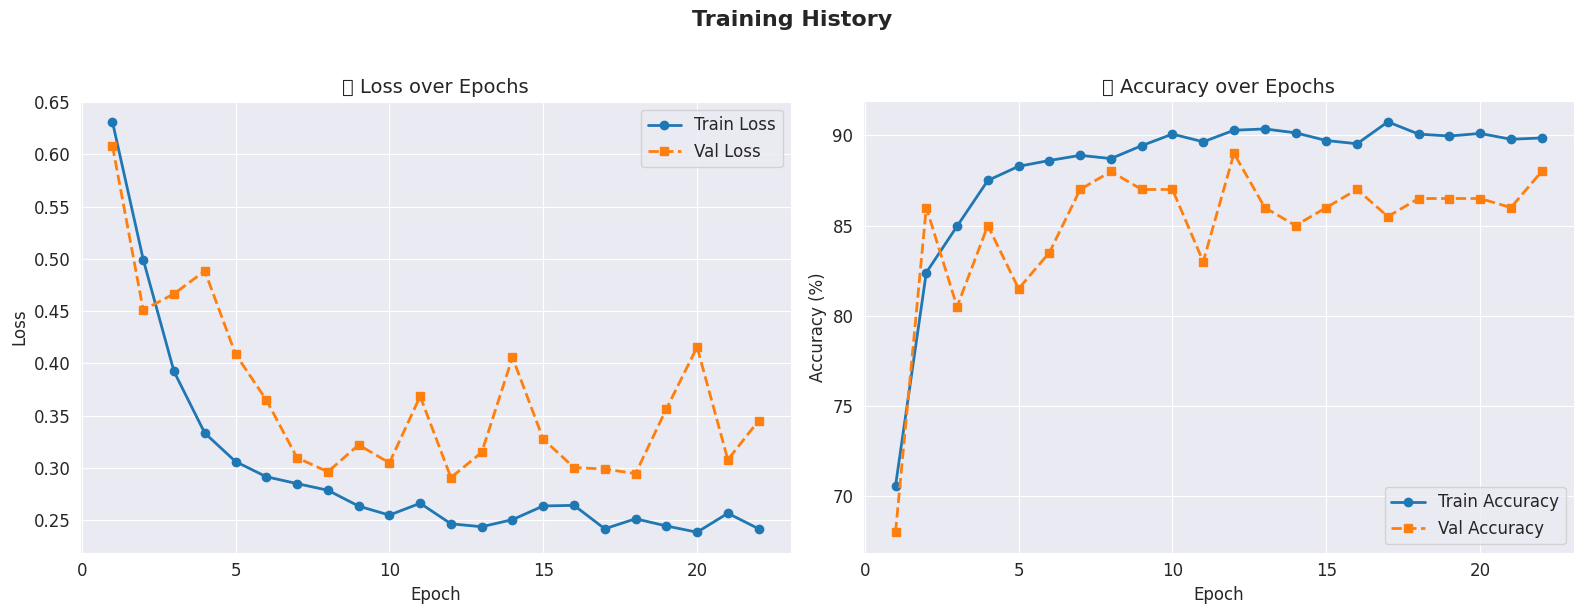

In [11]:
def plot_training_history(history: dict):
    """Plot loss & accuracy curves side-by-side."""
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(16, 6))

    # ── Loss ──
    ax_loss.plot(epochs_range, history["train_loss"], "o-", label="Train Loss", linewidth=2)
    ax_loss.plot(epochs_range, history["val_loss"], "s--", label="Val Loss", linewidth=2)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title("📉 Loss over Epochs")
    ax_loss.legend()
    ax_loss.grid(True)

    # ── Accuracy ──
    train_acc_pct = [a * 100 for a in history["train_accuracy"]]
    val_acc_pct   = [a * 100 for a in history["val_accuracy"]]
    ax_acc.plot(epochs_range, train_acc_pct, "o-", label="Train Accuracy", linewidth=2)
    ax_acc.plot(epochs_range, val_acc_pct, "s--", label="Val Accuracy", linewidth=2)
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy (%)")
    ax_acc.set_title("📈 Accuracy over Epochs")
    ax_acc.legend()
    ax_acc.grid(True)

    plt.suptitle("Training History", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_training_history(history)

## 8. Evaluation — Confusion Matrix & Classification Report

  Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


          📊 Classification Report
              precision    recall  f1-score   support

          no     0.8197    1.0000    0.9009       100
         yes     1.0000    0.7800    0.8764       100

    accuracy                         0.8900       200
   macro avg     0.9098    0.8900    0.8887       200
weighted avg     0.9098    0.8900    0.8887       200

  Overall Accuracy : 89.00%
  Precision (Tumor): 100.00%
  Recall    (Tumor): 78.00%
  F1-Score  (Tumor): 87.64%


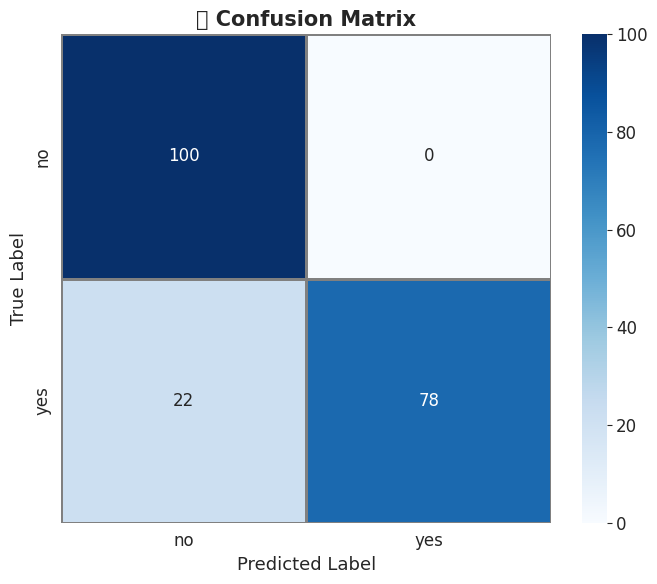

In [12]:
def get_all_predictions(model, loader, device):
    """Run inference on the full loader and return true/predicted labels."""
    model.eval()
    all_true = []
    all_pred = []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Evaluating", leave=False):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(predicted.cpu().numpy())
    return np.array(all_true), np.array(all_pred)


true_labels, predicted_labels = get_all_predictions(
    brain_tumor_model, val_loader, DEVICE
)

# ── Classification Report ──
print("\n" + "=" * 60)
print("          📊 Classification Report")
print("=" * 60)
print(classification_report(true_labels, predicted_labels,
                            target_names=class_names, digits=4))

overall_accuracy = accuracy_score(true_labels, predicted_labels) * 100
precision  = precision_score(true_labels, predicted_labels, average="binary", pos_label=1) * 100
recall     = recall_score(true_labels, predicted_labels, average="binary", pos_label=1) * 100
f1         = f1_score(true_labels, predicted_labels, average="binary", pos_label=1) * 100

print(f"  Overall Accuracy : {overall_accuracy:.2f}%")
print(f"  Precision (Tumor): {precision:.2f}%")
print(f"  Recall    (Tumor): {recall:.2f}%")
print(f"  F1-Score  (Tumor): {f1:.2f}%")
print("=" * 60)

# ── Confusion Matrix Heatmap ──
cm = confusion_matrix(true_labels, predicted_labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor="gray", ax=ax)
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title("🔬 Confusion Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

### 8.1 Performance Dashboard

A visual summary with horizontal gauge bars for key metrics.

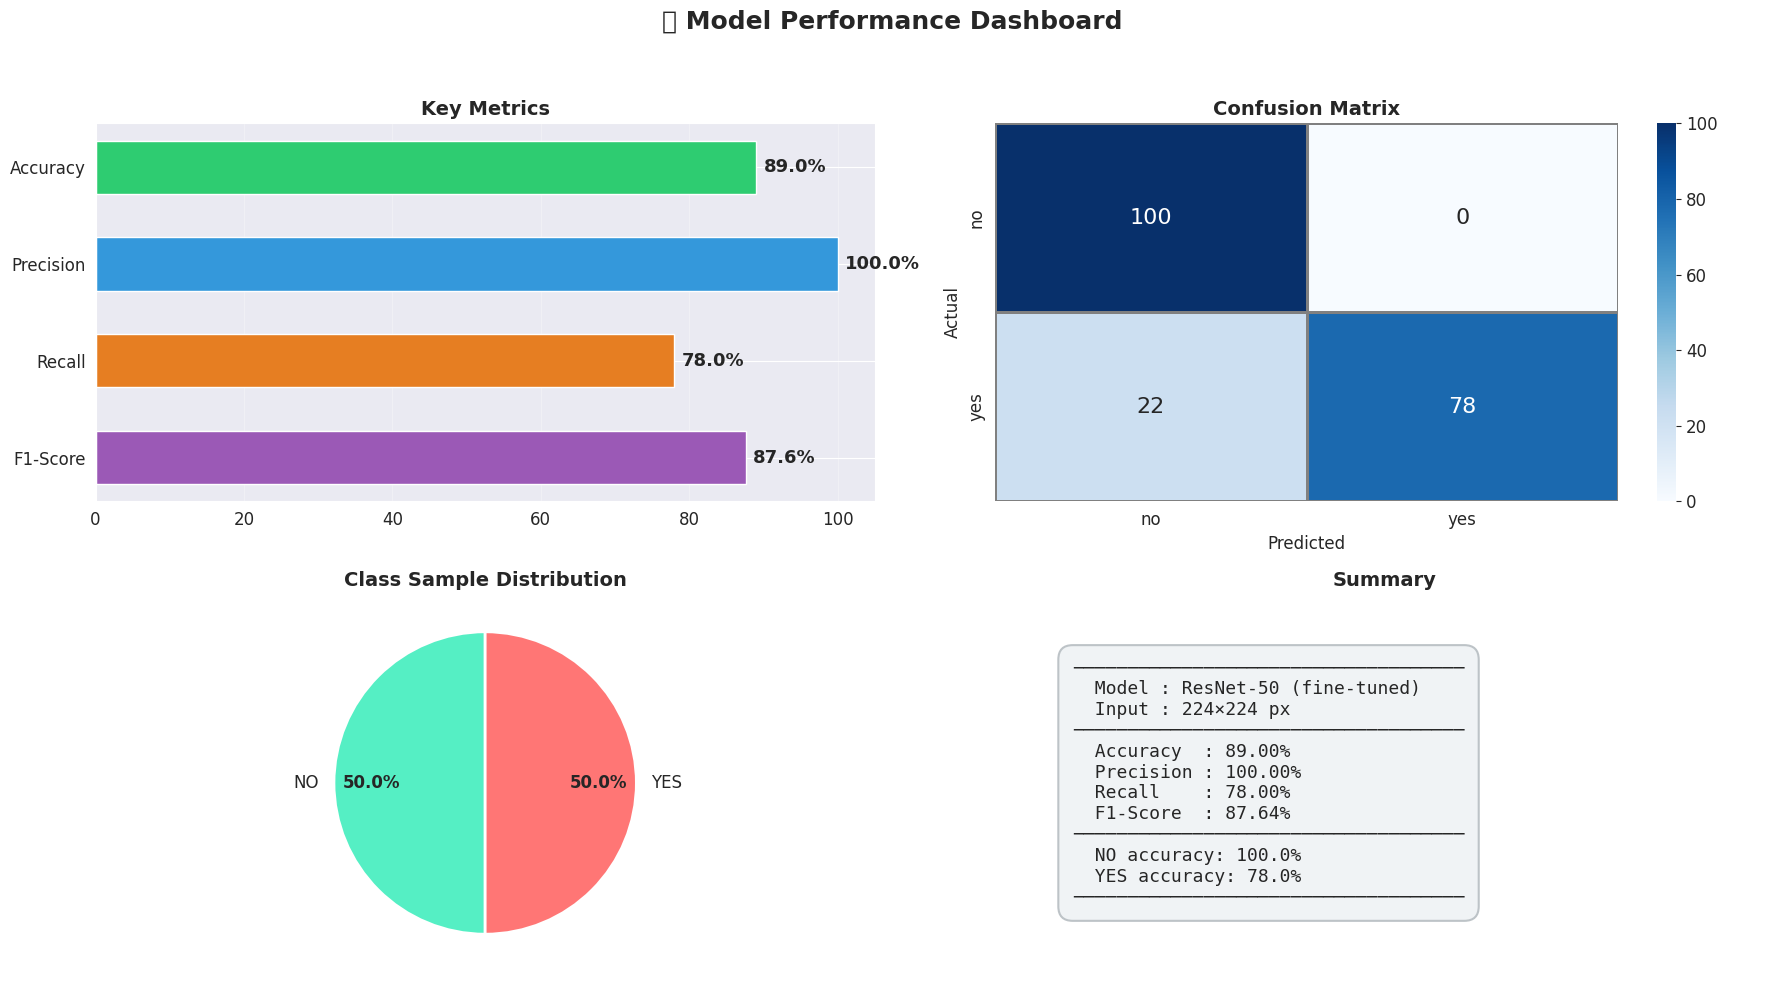

In [13]:
def plot_performance_dashboard(accuracy, precision, recall, f1,
                               class_names, cm):
    """Produce a 2×2 dashboard: metric bars, confusion matrix, pie, text summary."""
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle("🏥 Model Performance Dashboard", fontsize=18, fontweight="bold", y=0.98)

    # ── 1. Horizontal metric bars (top-left) ──
    ax1 = fig.add_subplot(2, 2, 1)
    metrics_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
    metrics_values = [accuracy, precision, recall, f1]
    colours = ["#2ecc71", "#3498db", "#e67e22", "#9b59b6"]
    bars = ax1.barh(metrics_names, metrics_values, color=colours,
                    edgecolor="white", height=0.55)
    ax1.set_xlim(0, 105)
    for bar, val in zip(bars, metrics_values):
        ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=13, fontweight="bold")
    ax1.set_title("Key Metrics", fontsize=14, fontweight="bold")
    ax1.invert_yaxis()
    ax1.grid(axis="x", alpha=0.3)

    # ── 2. Confusion matrix (top-right) ──
    ax2 = fig.add_subplot(2, 2, 2)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1, linecolor="gray", ax=ax2,
                annot_kws={"size": 16})
    ax2.set_xlabel("Predicted", fontsize=12)
    ax2.set_ylabel("Actual", fontsize=12)
    ax2.set_title("Confusion Matrix", fontsize=14, fontweight="bold")

    # ── 3. Per-class accuracy pie chart (bottom-left) ──
    ax3 = fig.add_subplot(2, 2, 3)
    correct_per_class = cm.diagonal()
    total_per_class   = cm.sum(axis=1)
    class_accuracies  = (correct_per_class / total_per_class * 100)
    wedge_colours = ["#55efc4", "#ff7675"]
    wedges, texts, autotexts = ax3.pie(
        total_per_class, labels=[c.upper() for c in class_names],
        autopct="%1.1f%%", startangle=90, colors=wedge_colours,
        textprops={"fontsize": 12}, pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 2})
    for t in autotexts:
        t.set_fontweight("bold")
    ax3.set_title("Class Sample Distribution", fontsize=14, fontweight="bold")

    # ── 4. Text summary card (bottom-right) ──
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.axis("off")
    summary_text = (
        f"{'─'*36}\n"
        f"  Model : ResNet-50 (fine-tuned)\n"
        f"  Input : {IMAGE_SIZE}×{IMAGE_SIZE} px\n"
        f"{'─'*36}\n"
        f"  Accuracy  : {accuracy:.2f}%\n"
        f"  Precision : {precision:.2f}%\n"
        f"  Recall    : {recall:.2f}%\n"
        f"  F1-Score  : {f1:.2f}%\n"
        f"{'─'*36}\n"
    )
    for i, class_name in enumerate(class_names):
        summary_text += f"  {class_name.upper()} accuracy: {class_accuracies[i]:.1f}%\n"
    summary_text += f"{'─'*36}"
    ax4.text(0.1, 0.5, summary_text, transform=ax4.transAxes,
             fontsize=13, verticalalignment="center",
             fontfamily="monospace",
             bbox=dict(boxstyle="round,pad=0.8", facecolor="#f0f3f5",
                       edgecolor="#bdc3c7", linewidth=1.5))
    ax4.set_title("Summary", fontsize=14, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_performance_dashboard(overall_accuracy, precision, recall, f1,
                           class_names, cm)

## 9. Inference Visualisation

Show a gallery of validation images with the model's prediction and
confidence overlaid.

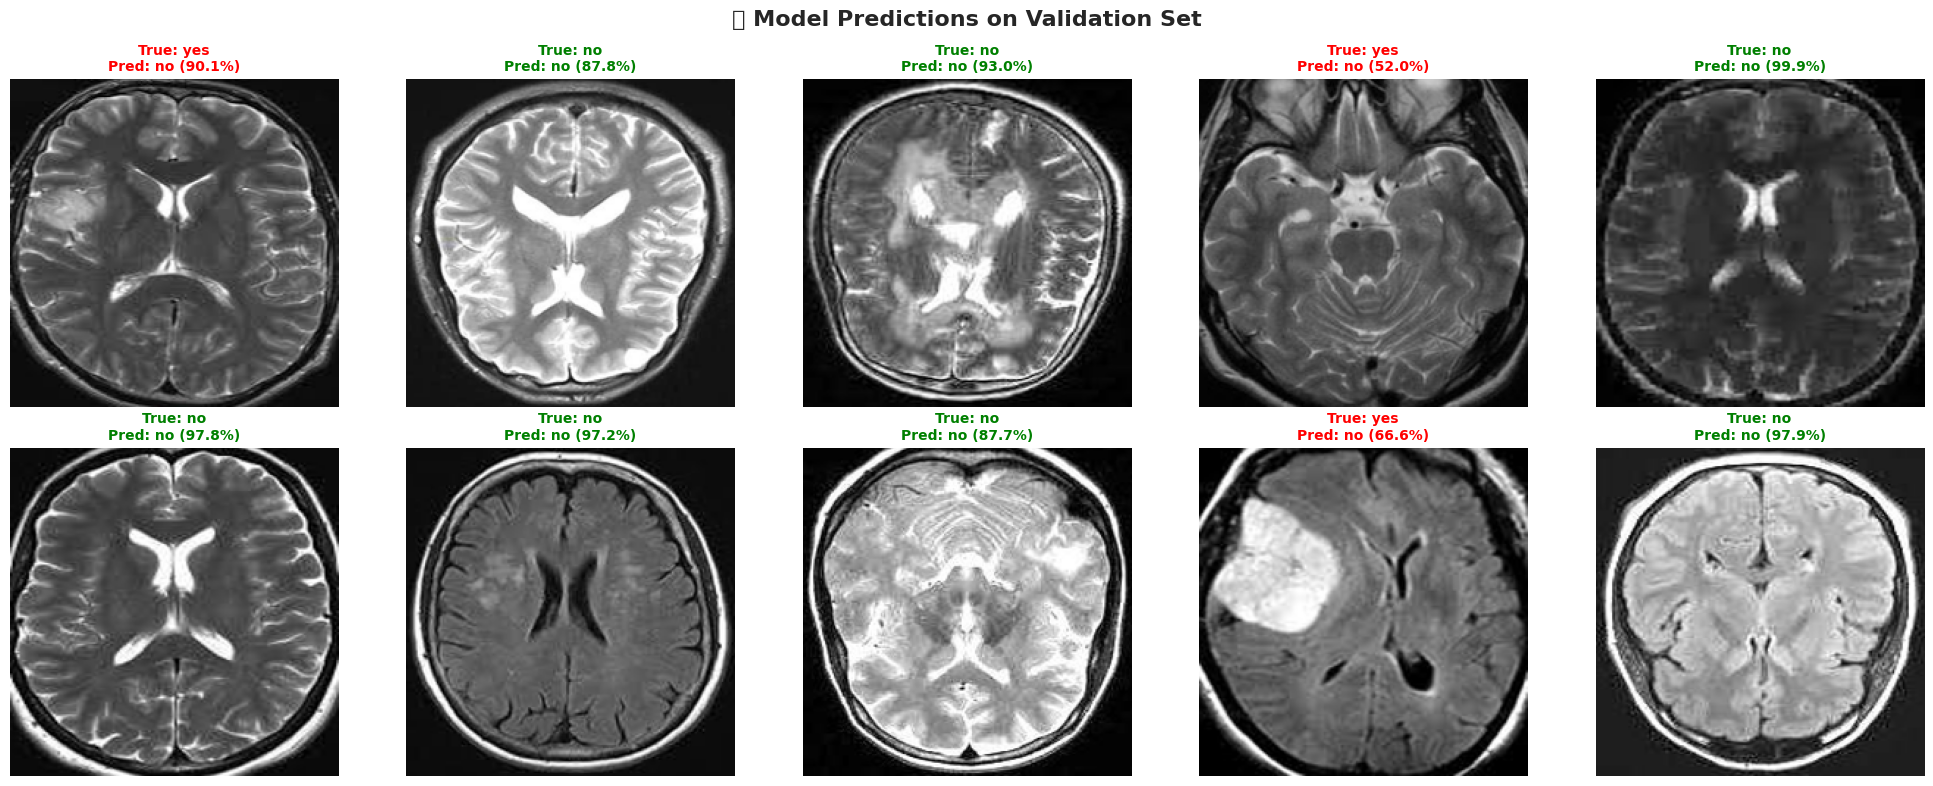

In [14]:
def visualise_predictions(model, dataset, class_names, device,
                          num_images: int = 10, seed: int = 42):
    """Display a grid of images with predicted labels and confidence."""
    rng = random.Random(seed)
    indices = rng.sample(range(len(dataset)), min(num_images, len(dataset)))

    cols = 5
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    fig.suptitle("🧠 Model Predictions on Validation Set",
                 fontsize=16, fontweight="bold")

    model.eval()
    for ax_idx, ax in enumerate(axes.flat):
        if ax_idx >= len(indices):
            ax.axis("off")
            continue

        sample_index = indices[ax_idx]
        raw_image = dataset.imgs[sample_index][0]
        true_label_idx = dataset.targets[sample_index]

        # For display only: re-open the original image without normalisation
        display_img = Image.open(raw_image).convert("RGB")
        display_img = crop_brain_contour(display_img, 2)
        display_img = display_img.resize((IMAGE_SIZE, IMAGE_SIZE))

        # Model prediction
        input_tensor = val_test_transforms(
            Image.open(raw_image).convert("RGB")
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

        predicted_class = class_names[predicted_idx.item()]
        true_class = class_names[true_label_idx]
        conf_pct = confidence.item() * 100
        is_correct = predicted_class == true_class

        ax.imshow(display_img)
        colour = "green" if is_correct else "red"
        ax.set_title(
            f"True: {true_class}\nPred: {predicted_class} ({conf_pct:.1f}%)",
            fontsize=10, color=colour, fontweight="bold",
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


visualise_predictions(brain_tumor_model, val_dataset, class_names, DEVICE,
                      num_images=10)

## 10. Contour Crop Visualisation

Step-by-step visualisation of the brain-contour extraction, replicating
the original notebook's preprocessing demo.

In [15]:
def visualise_contour_cropping(image_path: str):
    """Show the 4-step contour cropping pipeline for a single image."""
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    resized  = cv2.resize(original, (IMAGE_SIZE, IMAGE_SIZE),
                          interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary_mask = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)
    binary_mask = cv2.erode(binary_mask, None, iterations=2)
    binary_mask = cv2.dilate(binary_mask, None, iterations=2)

    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print("No contours found.")
        return

    largest = max(contours, key=cv2.contourArea)
    contour_img = resized.copy()
    cv2.drawContours(contour_img, [largest], -1, (0, 255, 255), 2)

    # Extreme points
    extreme_left  = tuple(largest[largest[:, :, 0].argmin()][0])
    extreme_right = tuple(largest[largest[:, :, 0].argmax()][0])
    extreme_top   = tuple(largest[largest[:, :, 1].argmin()][0])
    extreme_bot   = tuple(largest[largest[:, :, 1].argmax()][0])

    points_img = contour_img.copy()
    for point, colour in [(extreme_left, (255, 0, 0)),
                          (extreme_right, (0, 255, 0)),
                          (extreme_top, (0, 0, 255)),
                          (extreme_bot, (255, 255, 0))]:
        cv2.circle(points_img, point, 6, colour, -1)

    # Crop
    x, y, w, h = cv2.boundingRect(largest)
    cropped = resized[y:y+h, x:x+w]

    titles = [
        "Step 1 — Original Image",
        "Step 2 — Largest Contour",
        "Step 3 — Extreme Points",
        "Step 4 — Cropped Brain",
    ]
    images_list = [resized, contour_img, points_img, cropped]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle("🧠 Brain Contour Extraction Pipeline",
                 fontsize=15, fontweight="bold")
    for ax, img, title in zip(axes, images_list, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# Uncomment and set a valid image path to visualise cropping:
# visualise_contour_cropping("path/to/sample_mri_image.jpg")

## ✅ Summary

| Component | Detail |
|---|---|
| **Model** | ResNet-50 (pre-trained, fine-tuned) |
| **Input Size** | 224 × 224 |
| **Preprocessing** | Brain contour crop → Resize → Augment → Normalise |
| **Optimizer** | Adam (lr=1e-4, weight_decay=1e-4) |
| **Scheduler** | ReduceLROnPlateau |
| **Early Stopping** | Patience = 5 |
| **Outputs** | Training curves, confusion matrix, classification report, prediction gallery |